In [ ]:
from pathlib import Path
import pandas as pd

STATIC_PARAMETERS = {"RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}
STATIC_EXCLUDE = {"RecordID", "Age", "Gender", "Height", "ICUType"}

def hhmm_to_minutes(value: str) -> int:
    hours, minutes = value.split(":")
    return int(hours) * 60 + int(minutes)

def parse_patient_file(file_path: Path):
    df = pd.read_csv(file_path)
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

    record_rows = df.loc[df["Parameter"] == "RecordID", "Value"].dropna()
    patient_id = int(record_rows.iloc[0]) if not record_rows.empty else int(file_path.stem)

    static_df = df[df["Parameter"].isin(STATIC_PARAMETERS)].copy()
    static_df = static_df.drop_duplicates(subset=["Parameter"], keep="last")
    static_values = static_df.set_index("Parameter")["Value"].to_dict()

    static_record = {
        "RecordID": patient_id,
        "Age": static_values.get("Age"),
        "Gender": static_values.get("Gender"),
        "Height": static_values.get("Height"),
        "Weight": static_values.get("Weight"),
        "ICUType": static_values.get("ICUType"),
    }

    dynamic_df = df[~df["Parameter"].isin(STATIC_EXCLUDE)].copy()
    dynamic_df["Minutes"] = dynamic_df["Time"].map(hhmm_to_minutes)
    dynamic_df["RecordID"] = patient_id
    dynamic_df = dynamic_df[["RecordID", "Time", "Minutes", "Parameter", "Value"]]

    return static_record, dynamic_df

def load_cohort(folder: str):
    folder_path = Path(folder)
    static_records = []
    dynamic_tables = []

    for file_path in sorted(folder_path.glob("*.txt")):
        static_record, dynamic_df = parse_patient_file(file_path)
        static_records.append(static_record)
        dynamic_tables.append(dynamic_df)

    patients_static = pd.DataFrame(static_records).drop_duplicates(subset=["RecordID"])
    patients_static = patients_static.set_index("RecordID").sort_index()

    if dynamic_tables:
        patient_events = pd.concat(dynamic_tables, ignore_index=True)
        patient_events = patient_events.sort_values(["RecordID", "Minutes", "Parameter"]).reset_index(drop=True)
    else:
        patient_events = pd.DataFrame(columns=["RecordID", "Time", "Minutes", "Parameter", "Value"])

    return patients_static, patient_events

In [ ]:
train_data_location = "set-a"
patients_static, patient_events = load_cohort(train_data_location)

print(f"Number of patients: {patients_static.shape[0]}")
print(f"Number of dynamic observations: {patient_events.shape[0]}")

display(patients_static.head())
display(patient_events.head(15))

In [ ]:
#create a pivot table of patient_events
pivot_table = patient_events.pivot_table(index=["RecordID", "Time", "Minutes"], columns="Parameter", values="Value")
print("Pivot table of patient_events:")
# display(pivot_table.head(5))
#find how many columns are in the pivot table
print(f"Number of columns in the pivot table: {pivot_table.shape[1]}")
#make it a dataframe again
pivot_table = pivot_table.reset_index()
print("Pivot table of patient_events after resetting index:")
# display(pivot_table.head(5))
#join the static variables to the pivot table
pivot_table = pivot_table.merge(patients_static, on="RecordID", how="left")
pivot_table = pivot_table.sort_values(["RecordID", "Minutes"]).reset_index(drop=True)
print("Pivot table of patient_events after merging with patients_static:")
# display(pivot_table.head(5))
#values that gender variable can take
print(f"Unique values in Gender column: {pivot_table['Gender'].unique()}")
#minus one for the 'Gender' 0,1,-1
print(f"Number of columns in the pivot table after merging with patients_static: {pivot_table.shape[1]}")
print(f"pivot table columns: {pivot_table.columns.tolist()}")

In [ ]:
pivot_table

In [ ]:
#find unique parameters in patient_events
unique_parameters = patient_events["Parameter"].unique()
print(f"Unique parameters in patient_events: {unique_parameters}")
print(f"length of unique parameters: {len(unique_parameters)}")

In [ ]:
# load in outcomes for the training set (set-a)
outcomes = pd.read_csv("Outcomes-a.txt")
print(f"Number of outcome records: {outcomes.shape[0]}")
#number of null records
num_null_records = outcomes['In-hospital_death'].isnull().sum()
print(f"Number of null records in 'In-hospital_death': {num_null_records}")
outcomes#[['In-hospital_death']]

## Q1.1: Build Regular Hourly Time Grid

Convert irregularly-sampled events into a regular 49-step hourly grid (00:00–48:00).

**Rounding:** ceiling — a measurement at minute 37 goes into hour 1 (the first hour boundary at which we *know* that value), preserving temporal causality.

**Multiple values in same hour:** keep the last (most recent within that hour).

**Missing values:** filled with NaN for now (forward-fill in Q1.3).

In [ ]:
import numpy as np
import math

DYNAMIC_VARS = sorted([
    'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol',
    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
    'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP',
    'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2',
    'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH'
])  # 37 dynamic variables (Weight remains dynamic)

# Add StaticWeight as a separate static field
STATIC_VARS = ['Age', 'Gender', 'Height', 'StaticWeight', 'ICUType']

HOURS = list(range(49))  # hour slots 0..48  (00:00 to 48:00)


def build_hourly_grid(patients_static, patient_events):
    """
    Convert irregularly-sampled patient events into a regular 49-step hourly grid.

    Rounding: ceiling — minute 0 → hour 0, minute 1..60 → hour 1, etc.
    Multiple measurements for the same variable in the same hour: keep the last.
    Missing values are NaN (forward-fill later if desired).
    Static variables (including StaticWeight) are broadcast to all 49 rows.
    Weight is treated as a dynamic variable.
    """
    # Copy to avoid mutating caller; create StaticWeight snapshot from admission Weight
    ps = patients_static.copy()
    ps['StaticWeight'] = ps['Weight']

    df = patient_events.copy()

    # Ceiling: minute 0 → 0, minute 1..60 → 1, minute 61..120 → 2, ...
    df["hour"] = df["Minutes"].apply(lambda m: math.ceil(m / 60))

    # Discard anything beyond the 48h window
    df = df[df["hour"] <= 48]

    # Last measurement per (patient, hour, variable)
    df_last = (
        df.sort_values(["RecordID", "Minutes"])
          .groupby(["RecordID", "hour", "Parameter"])["Value"]
          .last()
          .unstack("Parameter")
    )

    # Ensure all dynamic cols exist
    for col in DYNAMIC_VARS:
        if col not in df_last.columns:
            df_last[col] = np.nan
    df_last = df_last[DYNAMIC_VARS]

    # Full grid: every patient × every hour 0..48
    all_patients = ps.index
    full_index = pd.MultiIndex.from_product([all_patients, HOURS], names=["RecordID", "hour"])
    grid = df_last.reindex(full_index).reset_index()

    # Broadcast statics (including StaticWeight)
    for col in STATIC_VARS:
        grid[col] = ps[col].reindex(grid["RecordID"]).values

    return grid[["RecordID", "hour"] + DYNAMIC_VARS + STATIC_VARS]


print("build_hourly_grid() defined.")
print(f"  Dynamic variables ({len(DYNAMIC_VARS)}): {DYNAMIC_VARS}")
print(f"  Static variables  ({len(STATIC_VARS)}): {STATIC_VARS}")
print(f"  Total data columns: {len(DYNAMIC_VARS) + len(STATIC_VARS)}")

In [ ]:
SETS = {
    "a": ("set-a", "Outcomes-a.txt"),
    "b": ("set-b", "Outcomes-b.txt"),
    "c": ("set-c", "Outcomes-c.txt"),
}

Path("processed").mkdir(exist_ok=True)

for split, (folder, outcomes_file) in SETS.items():
    print(f"\n--- Processing set-{split} ---")

    # Load raw data
    patients_static, patient_events = load_cohort(folder)
    print(f"  Patients: {len(patients_static)},  Events: {len(patient_events)}")

    # Build hourly grid
    grid = build_hourly_grid(patients_static, patient_events)
    expected_rows = len(patients_static) * 49
    print(f"  Grid shape: {grid.shape}  (expected {expected_rows} rows × {2 + len(DYNAMIC_VARS) + len(STATIC_VARS)} cols)")

    # Load and merge labels
    outcomes = pd.read_csv(outcomes_file)[["RecordID", "In-hospital_death"]]
    grid = grid.merge(outcomes, on="RecordID", how="left")

    # Save to parquet
    out_path = f"processed/set_{split}.parquet"
    grid.to_parquet(out_path, index=False)

    mortality_rate = grid.drop_duplicates("RecordID")["In-hospital_death"].mean()
    print(f"  Saved → {out_path}")
    print(f"  Mortality rate: {mortality_rate:.3f}")

In [ ]:
# Sanity check: reload set-a and inspect
df_a = pd.read_parquet("processed/set_a.parquet")

print(f"Shape: {df_a.shape}")
print(f"Columns ({len(df_a.columns)}): {df_a.columns.tolist()}")
print(f"\nRows per patient (should all be 49): {df_a.groupby('RecordID').size().unique().tolist()}")
print(f"\nMissing values (% of total rows), top 10 most sparse:")
print((df_a[DYNAMIC_VARS].isna().mean() * 100).sort_values(ascending=False).head(10).round(1).to_string())

# Show one patient's grid
sample_id = df_a["RecordID"].iloc[0]
print(f"\nSample patient {sample_id} — first 5 hours:")
display(df_a[df_a["RecordID"] == sample_id][["RecordID", "hour", "HR", "Temp", "Age", "Gender", "Urine", "NIDiasABP","In-hospital_death"]].head(6))

# Q1.2 Exploratory Data Analysis

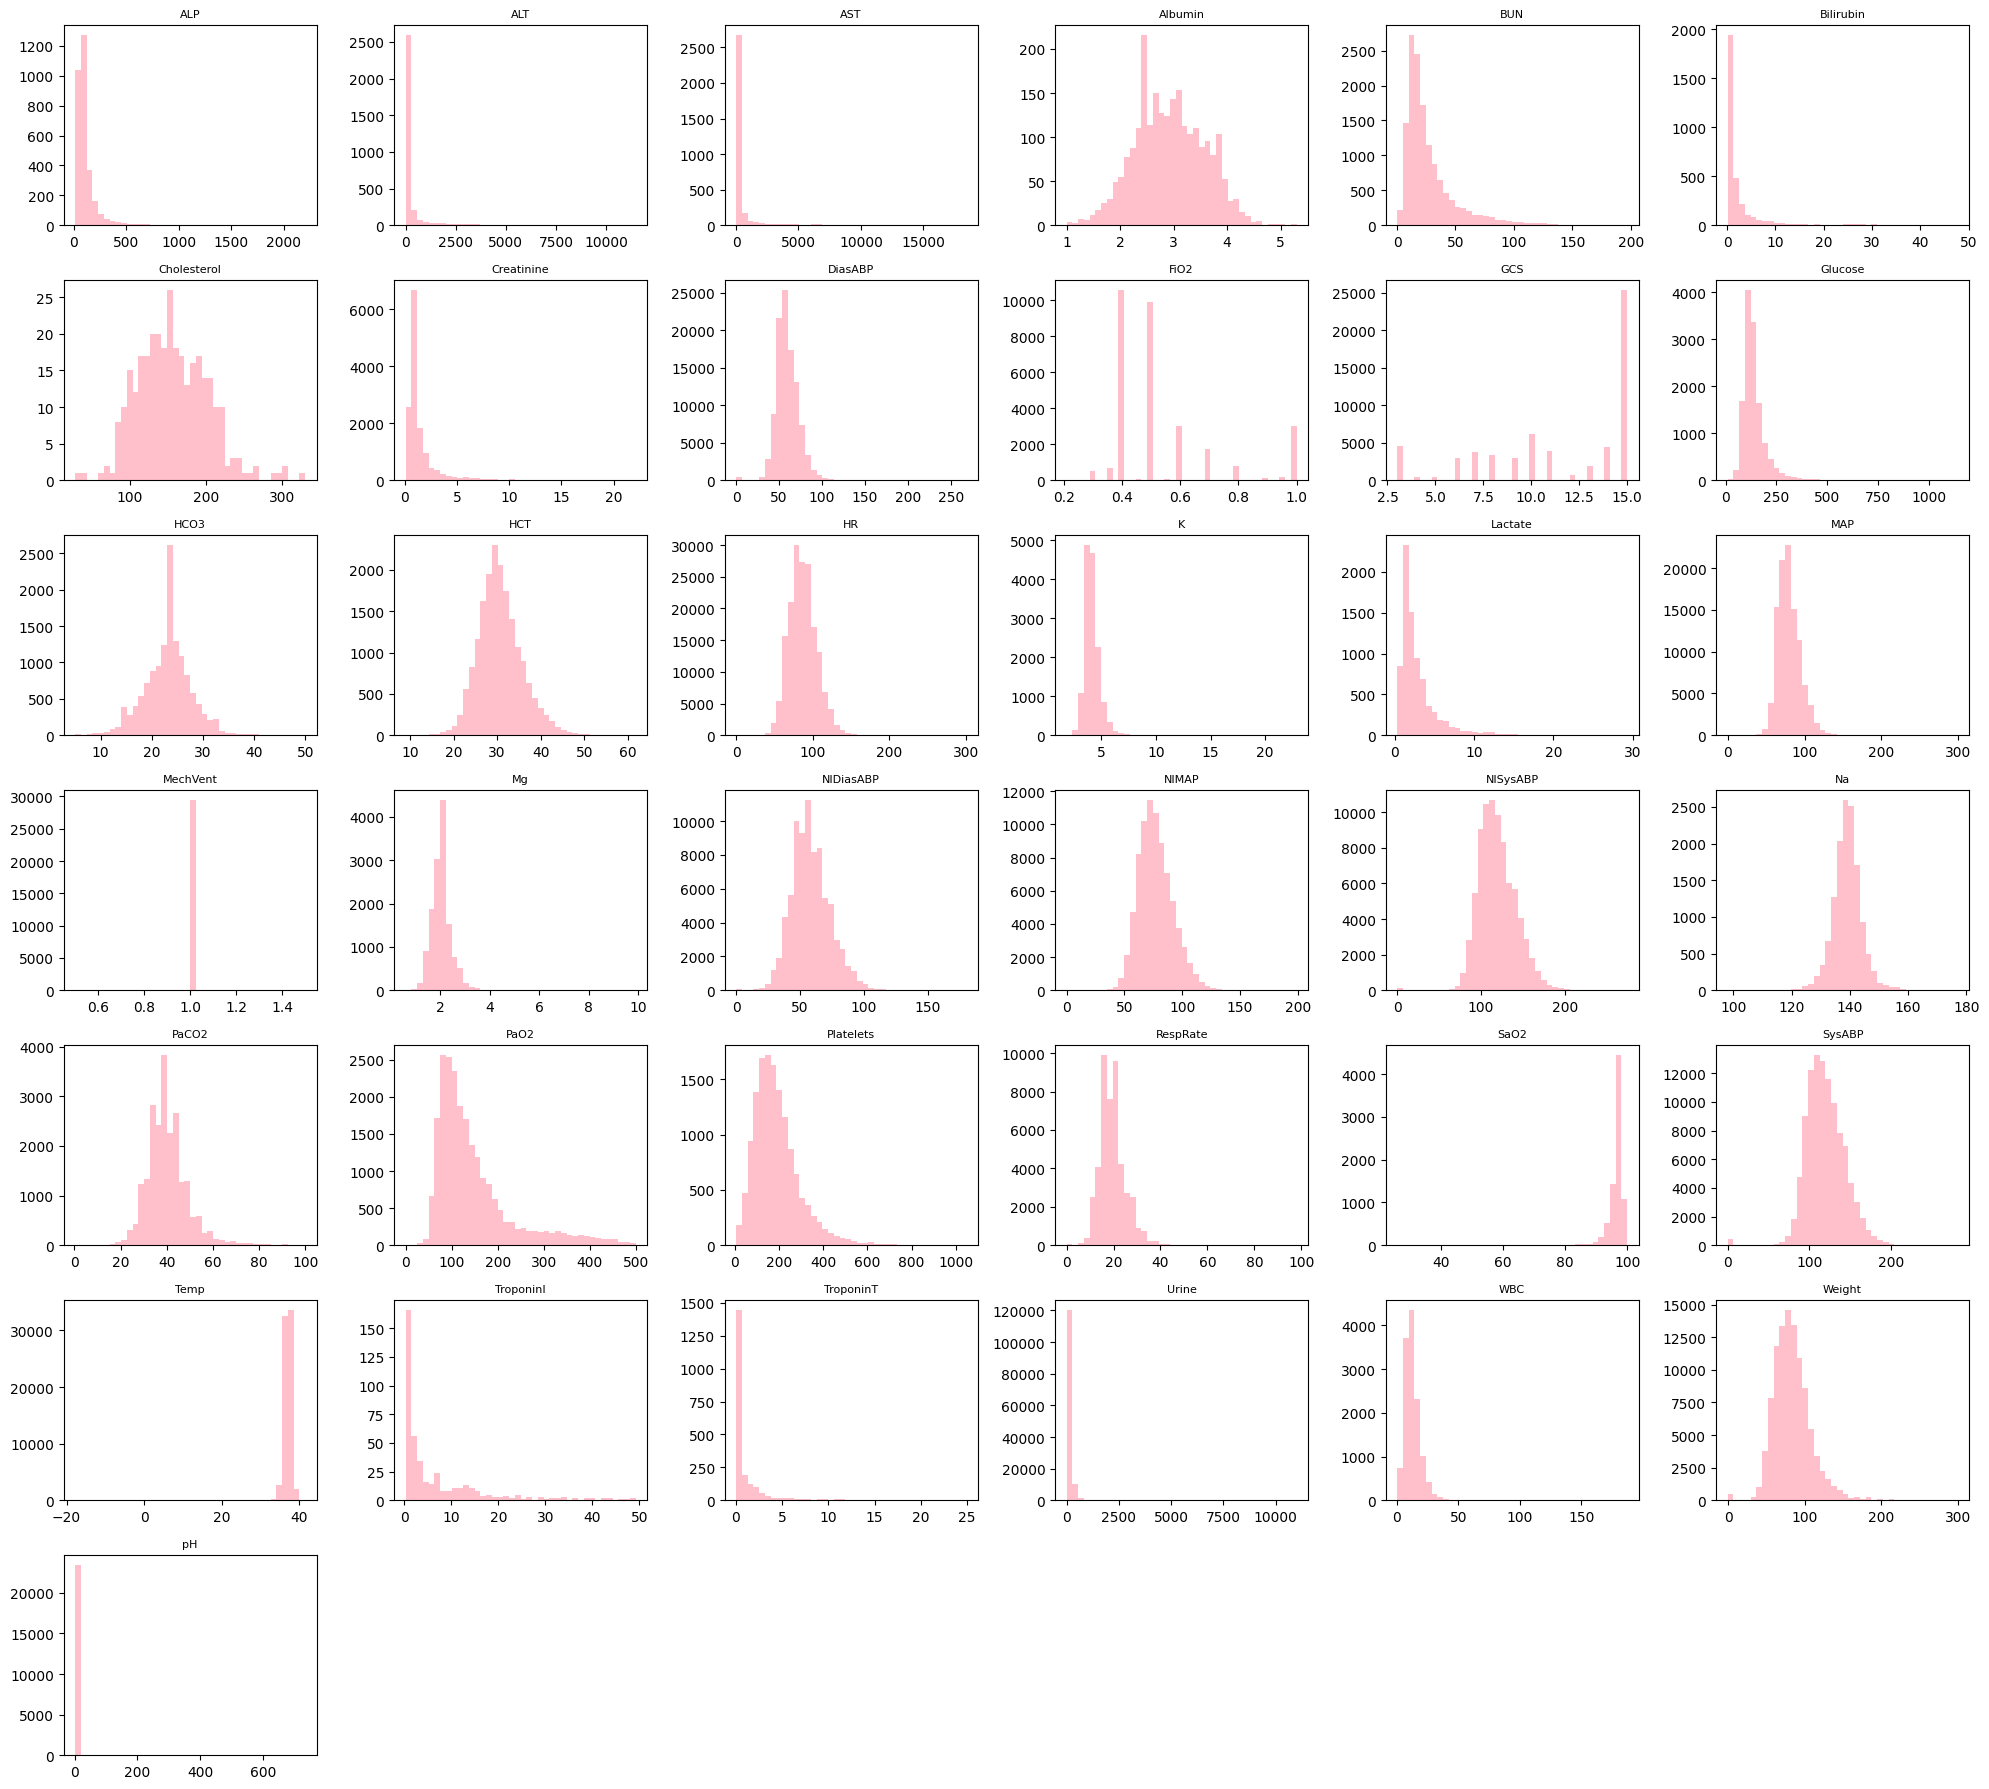

In [38]:
import matplotlib.pyplot as plt

# Plot all 37 dynamic variables in a grid
fig, axes = plt.subplots(7, 6, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(DYNAMIC_VARS):
    axes[i].hist(df_a[col].dropna(), bins=40, color='pink')
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [39]:
df_a[df_a["MechVent"] == 0]
# count number of nas in the MechVent column
num_nas_mechvent = df_a["MechVent"].isna().sum()
print(f"Number of NaN values in 'MechVent' column: {num_nas_mechvent}")
#number of values in total
total_values_mechvent = df_a["MechVent"].shape[0]
print(f"Total number of values in 'MechVent' column: {total_values_mechvent}")

Number of NaN values in 'MechVent' column: 166520
Total number of values in 'MechVent' column: 196000


## Interesting observations:
### First observation:
The MechVent (Mechanical ventilation respiration) has only values of 1 (true), which means they did not put any value when they MechVent was false (0), so we know for imputation we have to put 0 instead of NaN. 
 
### Second observation:
For the pH-value, we observed three values of 700. and five values of 100. The allowed scale is from 0 to 14, the other patients have values between 6.86 to 7.66. We will remove the values around 100, because we do not know what they should be, but the values of 700., we will devide by 100 as the comma was set wrong. There is also one value of 1 and one value of 3, which we noted ad suspicious. 
